In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("product_monthly_panel.csv")

# Drop columns with too many missing values
df = df.drop(columns=["hair_color", "eye_color", "skin_tone", "skin_type"])

# Drop rows with missing target or key numeric features
df = df.dropna(subset=["rating", "is_recommended", "helpfulness"])

# One-hot encode remaining categoricals
X = df.drop(columns=["rating"])
X = pd.get_dummies(X, drop_first=True)
y = df["rating"]


In [2]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [3]:
# Fill any remaining NaNs in test data
X_train = X_train.replace([np.inf, -np.inf], np.nan).dropna()
X_test = X_test.replace([np.inf, -np.inf], np.nan).fillna(0)

# Resync target to cleaned train
y_train = y_train.loc[X_train.index]



In [4]:
# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values.reshape(-1, 1), dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values.reshape(-1, 1), dtype=torch.float32)

# DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)


In [5]:
# Model
class FeedforwardNN(nn.Module):
    def __init__(self, input_dim):
        super(FeedforwardNN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)  # still unbounded
        )

    def forward(self, x):
        return self.model(x)

model = FeedforwardNN(X_train_tensor.shape[1])
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)


In [6]:
# Training
num_epochs = 50
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_x)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}, Loss: {epoch_loss / len(train_loader):.4f}")



Epoch 10, Loss: 0.1868
Epoch 20, Loss: 0.1206
Epoch 30, Loss: 0.0675
Epoch 40, Loss: 0.0448
Epoch 50, Loss: 0.0332


In [7]:
# Evaluation
model.eval()
with torch.no_grad():
    y_pred = model(X_test_tensor).numpy().flatten()
    y_true = y_test_tensor.numpy().flatten()

mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

print(f"\nMSE: {mse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²: {r2:.3f}")


MSE: 0.283
RMSE: 0.532
R²: 0.703


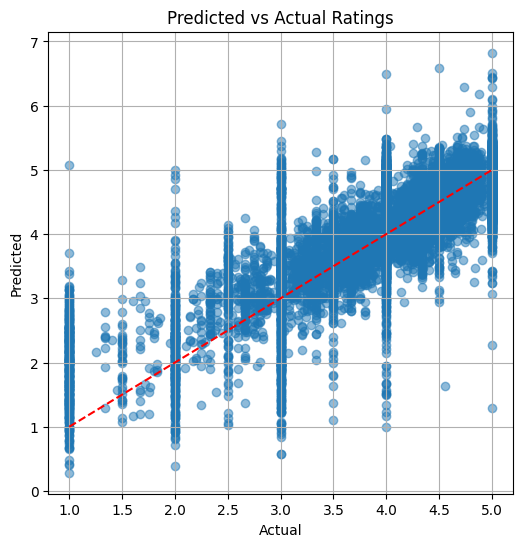

In [8]:
# Visualization
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.5)
plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual Ratings")
plt.grid(True)
plt.show()
